# 高股息 ETF 除息事件研究

## 讀取套件與資料

In [29]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.append(str(PROJECT_ROOT))

PANEL_PATH = PROJECT_ROOT / "data" / "processed" / "etf_daily_panel.csv"
EVENT_PATH = PROJECT_ROOT / "data" / "processed" / "etf_dividend_events.csv"

panel = pd.read_csv(
    PANEL_PATH,
    dtype={"symbol": str},
)

events = pd.read_csv(
    EVENT_PATH,
    dtype={"symbol": str},
)

panel["date"] = pd.to_datetime(panel["date"])
panel["symbol"] = panel["symbol"].astype(str)

events["ex_date"] = pd.to_datetime(events["ex_date"])
events["record_date"] = pd.to_datetime(events["record_date"], errors="coerce")
events["pay_date"] = pd.to_datetime(events["pay_date"], errors="coerce")
events["symbol"] = events["symbol"].astype(str)

panel = panel.sort_values(["symbol", "date"]).reset_index(drop=True)
events = events.sort_values(["symbol", "ex_date"]).reset_index(drop=True)

print("Panel shape:", panel.shape)
print("Panel date range:", panel["date"].min(), "to", panel["date"].max())
print("Panel symbols:", sorted(panel["symbol"].unique()))

print("\nEvents shape:", events.shape)
print("Events date range:", events["ex_date"].min(), "to", events["ex_date"].max())
print("Event symbols:", sorted(events["symbol"].unique()))

events.head()

Panel shape: (16224, 19)
Panel date range: 2016-01-04 00:00:00 to 2026-05-18 00:00:00
Panel symbols: ['0050', '0052', '0056', '006208', '00713', '00878', '00919', '00929', '00939', '00940']

Events shape: (108, 9)
Events date range: 2016-10-26 00:00:00 to 2029-09-22 00:00:00
Event symbols: ['0056', '00713', '00878', '00919', '00929']


,symbol,etf_name,ex_date,record_date,pay_date,dividend,source,source_url,scraped_at
0,0056,元大高股息,2016-10-26,2016-11-01,2016-11-28,1.30,TWSE ETF eFortune dividendList,https://www.twse.com.tw/zh/ETFortune/dividendL...,2026-06-12 10:15:59.762500
1,0056,元大高股息,2017-10-30,2017-11-05,2017-12-04,0.95,TWSE ETF eFortune dividendList,https://www.twse.com.tw/zh/ETFortune/dividendL...,2026-06-12 10:16:00.934230
2,0056,元大高股息,2018-10-23,2018-10-29,2018-11-27,1.45,TWSE ETF eFortune dividendList,https://www.twse.com.tw/zh/ETFortune/dividendL...,2026-06-12 10:16:02.285337
3,0056,元大高股息,2019-10-23,2019-10-29,2019-11-26,1.80,TWSE ETF eFortune dividendList,https://www.twse.com.tw/zh/ETFortune/dividendL...,2026-06-12 10:16:03.474818
4,0056,元大高股息,2020-10-28,2020-11-03,2020-12-01,1.60,TWSE ETF eFortune dividendList,https://www.twse.com.tw/zh/ETFortune/dividendL...,2026-06-12 10:16:04.955781


## 設定研究參數

In [30]:
universe = [
    "0056",
    "00713",
    "00878",
    "00919",
    "00929",
]

price_col = "adj_close"

window_before = 100
window_after = 100

fee_rate = 0.0008

panel = panel[panel["symbol"].isin(universe)].copy()
events = events[events["symbol"].isin(universe)].copy()

print("Filtered panel shape:", panel.shape)
print("Filtered events shape:", events.shape)

events.groupby("symbol")["ex_date"].agg(["min", "max", "count"])

Filtered panel shape: (7628, 19)
Filtered events shape: (108, 9)


,min,max,count
symbol,,,
0056,2016-10-26,2026-04-23,19
00713,2018-11-22,2026-03-20,19
00878,2020-11-17,2026-05-19,23
00919,2023-06-16,2026-03-17,12
00929,2023-07-19,2029-09-22,35


## 檢查事件資料是否能對上交易日

In [31]:
def check_event_date_matching(
    panel: pd.DataFrame,
    events: pd.DataFrame,
) -> pd.DataFrame:
    rows = []

    for _, event in events.iterrows():
        symbol = event["symbol"]
        ex_date = event["ex_date"]

        symbol_dates = set(
            panel.loc[panel["symbol"] == symbol, "date"]
        )

        matched = ex_date in symbol_dates

        rows.append({
            "symbol": symbol,
            "ex_date": ex_date,
            "matched_in_panel": matched,
        })

    return pd.DataFrame(rows)


match_check = check_event_date_matching(panel, events)

print(match_check["matched_in_panel"].value_counts())

match_check[match_check["matched_in_panel"] == False]

matched_in_panel
True     105
False      3
Name: count, dtype: int64


,symbol,ex_date,matched_in_panel
60,00878,2026-05-19,False
106,00929,2026-05-20,False
107,00929,2029-09-22,False


## 建立事件窗口資料

In [32]:
def build_event_window_data(
    panel: pd.DataFrame,
    events: pd.DataFrame,
    price_col: str = "adj_close",
    window_before: int = 10,
    window_after: int = 10,
) -> pd.DataFrame:
    """
    Build event window data around ETF ex-dividend dates.

    relative_day:
    - negative: before ex-date
    - 0: ex-date
    - positive: after ex-date
    """

    panel = panel.copy()
    events = events.copy()

    panel["date"] = pd.to_datetime(panel["date"])
    events["ex_date"] = pd.to_datetime(events["ex_date"])

    panel["symbol"] = panel["symbol"].astype(str)
    events["symbol"] = events["symbol"].astype(str)

    rows = []

    for _, event in events.iterrows():
        symbol = event["symbol"]
        ex_date = event["ex_date"]

        symbol_df = (
            panel[panel["symbol"] == symbol]
            .sort_values("date")
            .reset_index(drop=True)
            .copy()
        )

        if symbol_df.empty:
            continue

        matched_index = symbol_df.index[symbol_df["date"] == ex_date]

        if len(matched_index) == 0:
            continue

        ex_pos = matched_index[0]

        start_pos = max(0, ex_pos - window_before)
        end_pos = min(len(symbol_df) - 1, ex_pos + window_after)

        window_df = symbol_df.loc[start_pos:end_pos].copy()

        window_df["relative_day"] = window_df.index - ex_pos
        window_df["event_id"] = f"{symbol}_{ex_date.strftime('%Y%m%d')}"
        window_df["ex_date"] = ex_date
        window_df["record_date"] = event.get("record_date", pd.NaT)
        window_df["pay_date"] = event.get("pay_date", pd.NaT)
        window_df["dividend"] = event.get("dividend", np.nan)
        window_df["etf_name"] = event.get("etf_name", "")

        rows.append(window_df)

    if not rows:
        return pd.DataFrame()

    event_data = pd.concat(rows, ignore_index=True)

    keep_cols = [
        "event_id",
        "symbol",
        "etf_name",
        "ex_date",
        "record_date",
        "pay_date",
        "dividend",
        "relative_day",
        "date",
        "open",
        "close",
        "adj_close",
        "volume",
        "nav",
        "premium_discount",
    ]

    keep_cols = [col for col in keep_cols if col in event_data.columns]

    event_data = event_data[keep_cols].copy()

    return event_data


event_data = build_event_window_data(
    panel=panel,
    events=events,
    price_col=price_col,
    window_before=window_before,
    window_after=window_after,
)

print("Event data shape:", event_data.shape)
print("Event count:", event_data["event_id"].nunique())

event_data.head()

Event data shape: (20435, 15)
Event count: 105


,event_id,symbol,etf_name,ex_date,record_date,pay_date,dividend,relative_day,date,open,close,adj_close,volume,nav,premium_discount
0,0056_20161026,0056,元大高股息,2016-10-26,2016-11-01,2016-11-28,1.3,-100,2016-06-03,22.070000,22.030001,10.687209,2729288,22.21,-0.0081
1,0056_20161026,0056,元大高股息,2016-10-26,2016-11-01,2016-11-28,1.3,-99,2016-06-04,22.190001,22.190001,10.764828,0,22.19,-0.0063
2,0056_20161026,0056,元大高股息,2016-10-26,2016-11-01,2016-11-28,1.3,-98,2016-06-06,22.059999,21.980000,10.662951,2688011,22.12,-0.0063
3,0056_20161026,0056,元大高股息,2016-10-26,2016-11-01,2016-11-28,1.3,-97,2016-06-07,22.030001,22.290001,10.813339,6829710,22.48,-0.0085
4,0056_20161026,0056,元大高股息,2016-10-26,2016-11-01,2016-11-28,1.3,-96,2016-06-08,22.320000,22.360001,10.847299,3863745,22.54,-0.0080


## 檢查事件窗口完整性

In [33]:
event_window_check = (
    event_data
    .groupby("event_id")["relative_day"]
    .agg(["min", "max", "count"])
    .reset_index()
)

event_window_check["complete_window"] = (
    (event_window_check["min"] <= -window_before)
    & (event_window_check["max"] >= window_after)
)

print(event_window_check["complete_window"].value_counts())

event_window_check.head()

complete_window
True     88
False    17
Name: count, dtype: int64


,event_id,min,max,count,complete_window
0,0056_20161026,-100,100,201,True
1,0056_20171030,-100,100,201,True
2,0056_20181023,-100,100,201,True
3,0056_20191023,-100,100,201,True
4,0056_20201028,-100,100,201,True


In [34]:
complete_event_ids = event_window_check.loc[
    event_window_check["complete_window"],
    "event_id"
]

event_data_complete = event_data[
    event_data["event_id"].isin(complete_event_ids)
].copy()

print("Complete event data shape:", event_data_complete.shape)
print("Complete event count:", event_data_complete["event_id"].nunique())

Complete event data shape: (17688, 15)
Complete event count: 88


## 計算事件報酬

In [35]:
event_data_complete = (
    event_data_complete
    .sort_values(["event_id", "relative_day"])
    .copy()
)

event_data_complete["event_start_price"] = (
    event_data_complete
    .groupby("event_id")[price_col]
    .transform("first")
)

event_data_complete["cum_return_from_start"] = (
    event_data_complete[price_col]
    / event_data_complete["event_start_price"]
    - 1
)

event_data_complete["daily_return"] = (
    event_data_complete
    .groupby("event_id")[price_col]
    .pct_change()
)

event_data_complete.head()

,event_id,symbol,etf_name,ex_date,record_date,pay_date,dividend,relative_day,date,open,close,adj_close,volume,nav,premium_discount,event_start_price,cum_return_from_start,daily_return
0,0056_20161026,0056,元大高股息,2016-10-26,2016-11-01,2016-11-28,1.3,-100,2016-06-03,22.070000,22.030001,10.687209,2729288,22.21,-0.0081,10.687209,0.000000,NaN
1,0056_20161026,0056,元大高股息,2016-10-26,2016-11-01,2016-11-28,1.3,-99,2016-06-04,22.190001,22.190001,10.764828,0,22.19,-0.0063,10.687209,0.007263,0.007263
2,0056_20161026,0056,元大高股息,2016-10-26,2016-11-01,2016-11-28,1.3,-98,2016-06-06,22.059999,21.980000,10.662951,2688011,22.12,-0.0063,10.687209,-0.002270,-0.009464
3,0056_20161026,0056,元大高股息,2016-10-26,2016-11-01,2016-11-28,1.3,-97,2016-06-07,22.030001,22.290001,10.813339,6829710,22.48,-0.0085,10.687209,0.011802,0.014104
4,0056_20161026,0056,元大高股息,2016-10-26,2016-11-01,2016-11-28,1.3,-96,2016-06-08,22.320000,22.360001,10.847299,3863745,22.54,-0.0080,10.687209,0.014980,0.003141


## 畫平均事件累積報酬

In [36]:
avg_event_return = (
    event_data_complete
    .groupby("relative_day")["cum_return_from_start"]
    .agg(["mean", "median", "count"])
    .reset_index()
)

avg_event_return

,relative_day,mean,median,count
0,-100,0.000000,0.000000,88
1,-99,0.000389,0.000833,88
2,-98,0.001164,0.002498,88
3,-97,0.002519,0.003192,88
4,-96,0.004188,0.005882,88
...,...,...,...,...
196,96,0.123151,0.076494,88
197,97,0.123169,0.080658,88
198,98,0.125406,0.077991,88
199,99,0.126467,0.079673,88


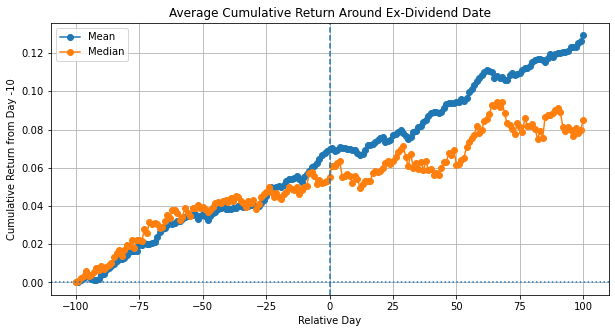

In [37]:
plt.figure(figsize=(10, 5))

plt.plot(
    avg_event_return["relative_day"].to_numpy(),
    avg_event_return["mean"].to_numpy(),
    marker="o",
    label="Mean",
)

plt.plot(
    avg_event_return["relative_day"].to_numpy(),
    avg_event_return["median"].to_numpy(),
    marker="o",
    label="Median",
)

plt.axvline(0, linestyle="--")
plt.axhline(0, linestyle=":")
plt.title("Average Cumulative Return Around Ex-Dividend Date")
plt.xlabel("Relative Day")
plt.ylabel("Cumulative Return from Day -10")
plt.legend()
plt.grid(True)
plt.show()

## 改用「除息日前一天」作為基準

In [38]:
def add_return_relative_to_day(
    event_data: pd.DataFrame,
    base_day: int,
    price_col: str,
    output_col: str,
) -> pd.DataFrame:
    df = event_data.copy()

    base_prices = (
        df[df["relative_day"] == base_day]
        .set_index("event_id")[price_col]
    )

    df["base_price"] = df["event_id"].map(base_prices)

    df[output_col] = df[price_col] / df["base_price"] - 1

    df = df.drop(columns=["base_price"])

    return df


event_data_complete = add_return_relative_to_day(
    event_data=event_data_complete,
    base_day=-1,
    price_col=price_col,
    output_col="return_vs_day_minus_1",
)

avg_return_vs_day_minus_1 = (
    event_data_complete
    .groupby("relative_day")["return_vs_day_minus_1"]
    .agg(["mean", "median", "count"])
    .reset_index()
)

avg_return_vs_day_minus_1

,relative_day,mean,median,count
0,-100,-0.055721,-0.050567,88
1,-99,-0.055384,-0.050230,88
2,-98,-0.054742,-0.050264,88
3,-97,-0.053661,-0.050208,88
4,-96,-0.052128,-0.046390,88
...,...,...,...,...
196,96,0.050672,0.041039,88
197,97,0.050793,0.044369,88
198,98,0.052876,0.052994,88
199,99,0.053791,0.053662,88


## 分析除息日前後 Premium

In [39]:
avg_premium = (
    event_data_complete
    .groupby("relative_day")["premium_discount"]
    .agg(["mean", "median", "count"])
    .reset_index()
)

avg_premium

,relative_day,mean,median,count
0,-100,-0.000472,0.00000,80
1,-99,-0.000360,0.00050,80
2,-98,-0.000784,-0.00010,80
3,-97,-0.000484,0.00000,79
4,-96,-0.000754,0.00000,79
...,...,...,...,...
196,96,-0.000799,-0.00085,76
197,97,-0.000711,-0.00050,72
198,98,-0.001000,-0.00140,75
199,99,-0.000988,-0.00060,77


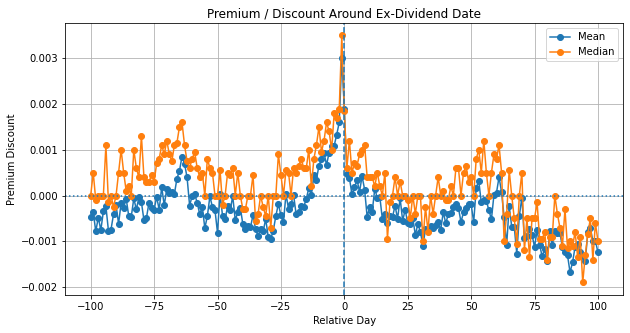

In [40]:
plt.figure(figsize=(10, 5))

plt.plot(
    avg_premium["relative_day"].to_numpy(),
    avg_premium["mean"].to_numpy(),
    marker="o",
    label="Mean",
)

plt.plot(
    avg_premium["relative_day"].to_numpy(),
    avg_premium["median"].to_numpy(),
    marker="o",
    label="Median",
)

plt.axvline(0, linestyle="--")
plt.axhline(0, linestyle=":")
plt.title("Premium / Discount Around Ex-Dividend Date")
plt.xlabel("Relative Day")
plt.ylabel("Premium Discount")
plt.legend()
plt.grid(True)
plt.show()

## 分析成交量變化

In [41]:
pre_event_volume_median = (
    event_data_complete[event_data_complete["relative_day"] < 0]
    .groupby("event_id")["volume"]
    .median()
)

event_data_complete["pre_event_volume_median"] = (
    event_data_complete["event_id"]
    .map(pre_event_volume_median)
)

event_data_complete["volume_ratio"] = (
    event_data_complete["volume"]
    / event_data_complete["pre_event_volume_median"]
)

avg_volume_ratio = (
    event_data_complete
    .groupby("relative_day")["volume_ratio"]
    .agg(["mean", "median", "count"])
    .reset_index()
)

avg_volume_ratio

,relative_day,mean,median,count
0,-100,1.109847,0.949269,88
1,-99,1.060120,0.840621,88
2,-98,1.018634,0.839139,88
3,-97,1.059683,0.857137,88
4,-96,1.102833,0.899414,88
...,...,...,...,...
196,96,1.724710,1.018301,88
197,97,1.974571,1.090276,88
198,98,1.741823,0.972066,88
199,99,1.760849,1.076107,88


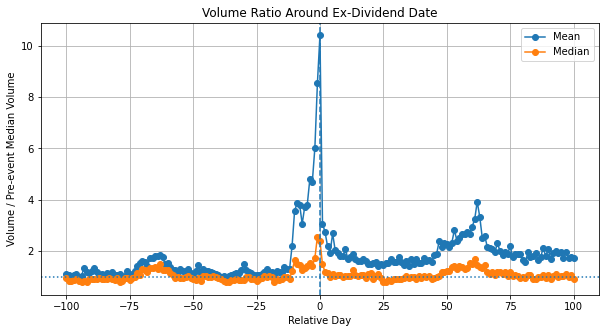

In [42]:
plt.figure(figsize=(10, 5))

plt.plot(
    avg_volume_ratio["relative_day"].to_numpy(),
    avg_volume_ratio["mean"].to_numpy(),
    marker="o",
    label="Mean",
)

plt.plot(
    avg_volume_ratio["relative_day"].to_numpy(),
    avg_volume_ratio["median"].to_numpy(),
    marker="o",
    label="Median",
)

plt.axvline(0, linestyle="--")
plt.axhline(1, linestyle=":")
plt.title("Volume Ratio Around Ex-Dividend Date")
plt.xlabel("Relative Day")
plt.ylabel("Volume / Pre-event Median Volume")
plt.legend()
plt.grid(True)
plt.show()

## 分 ETF 看累積報酬

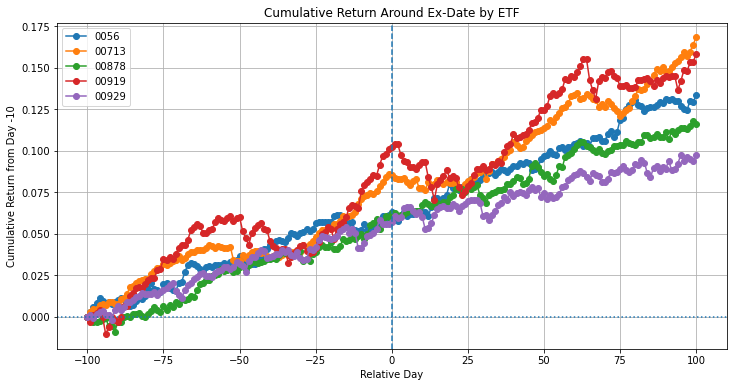

In [43]:
by_symbol_return = (
    event_data_complete
    .groupby(["symbol", "relative_day"])["cum_return_from_start"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(12, 6))

for symbol in universe:
    tmp = by_symbol_return[by_symbol_return["symbol"] == symbol]

    if tmp.empty:
        continue

    plt.plot(
        tmp["relative_day"].to_numpy(),
        tmp["cum_return_from_start"].to_numpy(),
        marker="o",
        label=symbol,
    )

plt.axvline(0, linestyle="--")
plt.axhline(0, linestyle=":")
plt.title("Cumulative Return Around Ex-Date by ETF")
plt.xlabel("Relative Day")
plt.ylabel("Cumulative Return from Day -10")
plt.legend()
plt.grid(True)
plt.show()

## 分 ETF 看 Premium

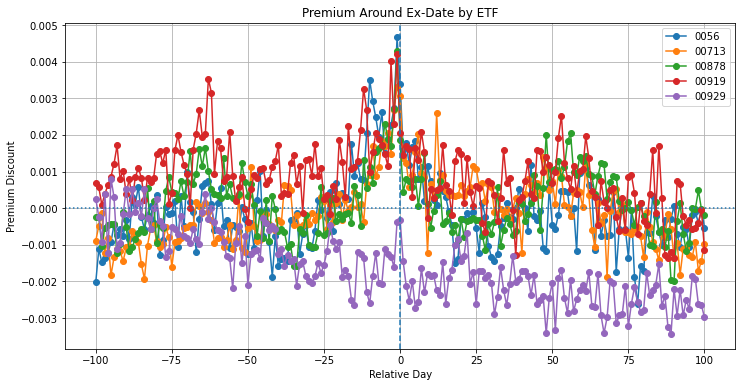

In [44]:
by_symbol_premium = (
    event_data_complete
    .groupby(["symbol", "relative_day"])["premium_discount"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(12, 6))

for symbol in universe:
    tmp = by_symbol_premium[by_symbol_premium["symbol"] == symbol]

    if tmp.empty:
        continue

    plt.plot(
        tmp["relative_day"].to_numpy(),
        tmp["premium_discount"].to_numpy(),
        marker="o",
        label=symbol,
    )

plt.axvline(0, linestyle="--")
plt.axhline(0, linestyle=":")
plt.title("Premium Around Ex-Date by ETF")
plt.xlabel("Relative Day")
plt.ylabel("Premium Discount")
plt.legend()
plt.grid(True)
plt.show()

## 分 ETF 看成交量

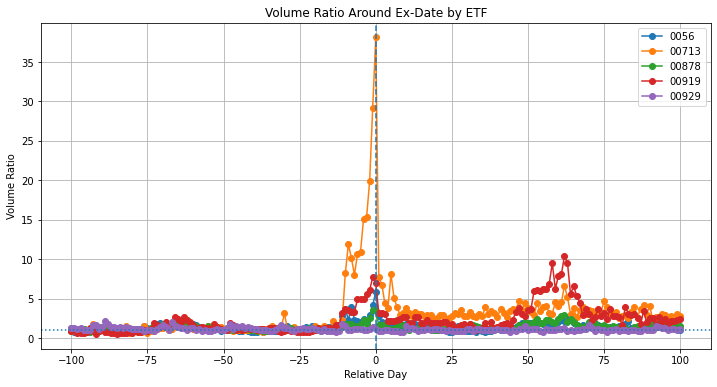

In [45]:
by_symbol_volume = (
    event_data_complete
    .groupby(["symbol", "relative_day"])["volume_ratio"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(12, 6))

for symbol in universe:
    tmp = by_symbol_volume[by_symbol_volume["symbol"] == symbol]

    if tmp.empty:
        continue

    plt.plot(
        tmp["relative_day"].to_numpy(),
        tmp["volume_ratio"].to_numpy(),
        marker="o",
        label=symbol,
    )

plt.axvline(0, linestyle="--")
plt.axhline(1, linestyle=":")
plt.title("Volume Ratio Around Ex-Date by ETF")
plt.xlabel("Relative Day")
plt.ylabel("Volume Ratio")
plt.legend()
plt.grid(True)
plt.show()

## 建立事件層級交易報酬函數

In [46]:
def calculate_event_trade_return(
    event_data: pd.DataFrame,
    price_col: str,
    entry_day: int,
    exit_day: int,
    fee_rate: float = 0.0008,
) -> pd.DataFrame:
    """
    Calculate event-level trade returns.

    entry_day / exit_day are relative days.
    """

    rows = []

    for event_id, g in event_data.groupby("event_id"):
        g = g.set_index("relative_day").sort_index()

        if entry_day not in g.index or exit_day not in g.index:
            continue

        entry_price = g.loc[entry_day, price_col]
        exit_price = g.loc[exit_day, price_col]

        if pd.isna(entry_price) or pd.isna(exit_price):
            continue

        raw_return = exit_price / entry_price - 1
        net_return = raw_return - 2 * fee_rate

        row = {
            "event_id": event_id,
            "symbol": g.loc[entry_day, "symbol"],
            "etf_name": g.loc[entry_day, "etf_name"],
            "ex_date": g.loc[entry_day, "ex_date"],
            "dividend": g.loc[entry_day, "dividend"],
            "entry_day": entry_day,
            "exit_day": exit_day,
            "entry_date": g.loc[entry_day, "date"],
            "exit_date": g.loc[exit_day, "date"],
            "entry_price": entry_price,
            "exit_price": exit_price,
            "raw_return": raw_return,
            "net_return": net_return,
        }

        rows.append(row)

    return pd.DataFrame(rows)

## 策略 A — 除息前追息

In [47]:
pre_div_trades = calculate_event_trade_return(
    event_data=event_data_complete,
    price_col=price_col,
    entry_day=-10,
    exit_day=-1,
    fee_rate=fee_rate,
)

pre_div_metrics = {
    "trade_count": len(pre_div_trades),
    "avg_raw_return": pre_div_trades["raw_return"].mean(),
    "avg_net_return": pre_div_trades["net_return"].mean(),
    "median_net_return": pre_div_trades["net_return"].median(),
    "win_rate": (pre_div_trades["net_return"] > 0).mean(),
    "total_net_return_sum": pre_div_trades["net_return"].sum(),
}

pd.Series(pre_div_metrics).to_frame("pre_div_momentum")

,pre_div_momentum
trade_count,88.000000
avg_raw_return,0.013447
avg_net_return,0.011847
median_net_return,0.007752
win_rate,0.625000
total_net_return_sum,1.042530


In [48]:
pre_div_by_symbol = (
    pre_div_trades
    .groupby("symbol")["net_return"]
    .agg(["count", "mean", "median", "sum"])
)

pre_div_by_symbol["win_rate"] = (
    pre_div_trades
    .assign(win=pre_div_trades["net_return"] > 0)
    .groupby("symbol")["win"]
    .mean()
)

pre_div_by_symbol

,count,mean,median,sum,win_rate
symbol,,,,,
0056,17,0.008022,-0.001221,0.136377,0.470588
00713,17,0.011698,0.005223,0.198868,0.647059
00878,20,0.009593,0.013244,0.191851,0.700000
00919,10,0.020846,0.016662,0.208456,0.800000
00929,24,0.012791,0.006339,0.306977,0.583333


## 策略 B — 除息後反轉 / 填息

In [49]:
post_div_trades = calculate_event_trade_return(
    event_data=event_data_complete,
    price_col=price_col,
    entry_day=0,
    exit_day=5,
    fee_rate=fee_rate,
)

post_div_metrics = {
    "trade_count": len(post_div_trades),
    "avg_raw_return": post_div_trades["raw_return"].mean(),
    "avg_net_return": post_div_trades["net_return"].mean(),
    "median_net_return": post_div_trades["net_return"].median(),
    "win_rate": (post_div_trades["net_return"] > 0).mean(),
    "total_net_return_sum": post_div_trades["net_return"].sum(),
}

pd.Series(post_div_metrics).to_frame("post_div_reversal")

,post_div_reversal
trade_count,88.000000
avg_raw_return,0.000561
avg_net_return,-0.001039
median_net_return,0.000776
win_rate,0.522727
total_net_return_sum,-0.091408


In [50]:
post_div_by_symbol = (
    post_div_trades
    .groupby("symbol")["net_return"]
    .agg(["count", "mean", "median", "sum"])
)

post_div_by_symbol["win_rate"] = (
    post_div_trades
    .assign(win=post_div_trades["net_return"] > 0)
    .groupby("symbol")["win"]
    .mean()
)

post_div_by_symbol

,count,mean,median,sum,win_rate
symbol,,,,,
0056,17,-0.004171,-0.005843,-0.070899,0.470588
00713,17,-0.005423,-0.006230,-0.092198,0.352941
00878,20,-0.000929,-0.000519,-0.018584,0.500000
00919,10,-0.009537,-0.008437,-0.095367,0.400000
00929,24,0.007735,0.007693,0.185640,0.750000


## 策略 C — 除息前 Premium 是否預測除息後報酬

In [51]:
event_summary_rows = []

for event_id, g in event_data_complete.groupby("event_id"):
    g = g.set_index("relative_day").sort_index()

    required_days = [-1, 0, 3, 5, 10]

    if not all(day in g.index for day in required_days):
        continue

    row = {
        "event_id": event_id,
        "symbol": g.loc[-1, "symbol"],
        "etf_name": g.loc[-1, "etf_name"],
        "ex_date": g.loc[-1, "ex_date"],
        "dividend": g.loc[-1, "dividend"],
        "premium_day_minus_1": g.loc[-1, "premium_discount"],
        "premium_day_0": g.loc[0, "premium_discount"],
        "premium_day_5": g.loc[5, "premium_discount"],
        "premium_change_0_to_5": (
            g.loc[5, "premium_discount"]
            - g.loc[0, "premium_discount"]
        ),
        "ret_0_to_3": g.loc[3, price_col] / g.loc[0, price_col] - 1,
        "ret_0_to_5": g.loc[5, price_col] / g.loc[0, price_col] - 1,
        "ret_0_to_10": g.loc[10, price_col] / g.loc[0, price_col] - 1,
    }

    event_summary_rows.append(row)

event_summary = pd.DataFrame(event_summary_rows)

event_summary.head()

,event_id,symbol,etf_name,ex_date,dividend,premium_day_minus_1,premium_day_0,premium_day_5,premium_change_0_to_5,ret_0_to_3,ret_0_to_5,ret_0_to_10
0,0056_20161026,0056,元大高股息,2016-10-26,1.30,0.0088,0.0034,0.0047,0.0013,0.000420,-0.021438,-0.044977
1,0056_20171030,0056,元大高股息,2017-10-30,0.95,0.0053,0.0111,0.0035,-0.0076,0.006667,0.003922,-0.019608
2,0056_20181023,0056,元大高股息,2018-10-23,1.45,0.0114,0.0058,0.0047,-0.0011,-0.029009,-0.029424,-0.002072
3,0056_20191023,0056,元大高股息,2019-10-23,1.80,0.0028,NaN,0.0029,NaN,0.005810,0.003994,0.014161
4,0056_20201028,0056,元大高股息,2020-10-28,1.60,0.0037,0.0028,0.0011,-0.0017,-0.016672,-0.004966,0.010997


In [52]:
event_summary[
    [
        "premium_day_minus_1",
        "premium_day_0",
        "premium_change_0_to_5",
        "ret_0_to_3",
        "ret_0_to_5",
        "ret_0_to_10",
    ]
].corr()

,premium_day_minus_1,premium_day_0,premium_change_0_to_5,ret_0_to_3,ret_0_to_5,ret_0_to_10
premium_day_minus_1,1.000000,0.642633,0.014222,-0.090390,-0.094710,-0.014314
premium_day_0,0.642633,1.000000,-0.411018,-0.157630,-0.191579,-0.131919
premium_change_0_to_5,0.014222,-0.411018,1.000000,-0.011264,-0.202215,-0.077351
ret_0_to_3,-0.090390,-0.157630,-0.011264,1.000000,0.813688,0.494286
ret_0_to_5,-0.094710,-0.191579,-0.202215,0.813688,1.000000,0.644766
ret_0_to_10,-0.014314,-0.131919,-0.077351,0.494286,0.644766,1.000000


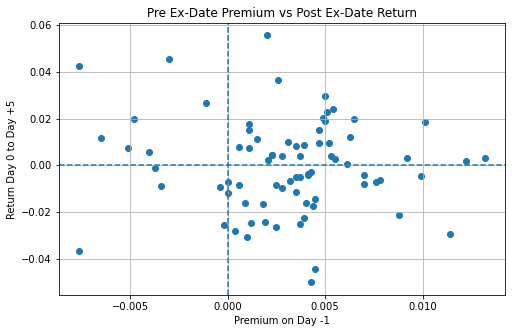

In [53]:
plt.figure(figsize=(8, 5))

plt.scatter(
    event_summary["premium_day_minus_1"].to_numpy(),
    event_summary["ret_0_to_5"].to_numpy(),
)

plt.axhline(0, linestyle="--")
plt.axvline(0, linestyle="--")
plt.title("Pre Ex-Date Premium vs Post Ex-Date Return")
plt.xlabel("Premium on Day -1")
plt.ylabel("Return Day 0 to Day +5")
plt.grid(True)
plt.show()

## 用 Premium 分組檢查

In [54]:
premium_threshold = event_summary["premium_day_minus_1"].median()

event_summary["premium_group"] = np.where(
    event_summary["premium_day_minus_1"] >= premium_threshold,
    "high_premium",
    "low_premium",
)

premium_group_perf = (
    event_summary
    .groupby("premium_group")
    [
        [
            "ret_0_to_3",
            "ret_0_to_5",
            "ret_0_to_10",
            "premium_change_0_to_5",
        ]
    ]
    .agg(["count", "mean", "median"])
)

premium_group_perf

ret_0_to_3                     ret_0_to_5                      \
                   count      mean    median      count      mean    median   
premium_group                                                                 
high_premium          40 -0.002250  0.000708         40 -0.001720 -0.001221   
low_premium           48  0.000947  0.001552         48  0.002462  0.004105   

              ret_0_to_10                     premium_change_0_to_5            \
                    count      mean    median                 count      mean   
premium_group                                                                   
high_premium           40 -0.001378 -0.002421                    39 -0.001944   
low_premium            48 -0.000033 -0.000370                    34 -0.001335   

                       
               median  
premium_group          
high_premium  -0.0011  
low_premium   -0.0011

## 初步結論表

In [55]:
summary_table = pd.DataFrame({
    "pre_div_momentum": pd.Series(pre_div_metrics),
    "post_div_reversal": pd.Series(post_div_metrics),
})

summary_table

,pre_div_momentum,post_div_reversal
trade_count,88.000000,88.000000
avg_raw_return,0.013447,0.000561
avg_net_return,0.011847,-0.001039
median_net_return,0.007752,0.000776
win_rate,0.625000,0.522727
total_net_return_sum,1.042530,-0.091408


## 輸出事件資料供後續使用

In [56]:
OUTPUT_DIR = PROJECT_ROOT / "data" / "research"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

event_data_output_path = OUTPUT_DIR / "high_dividend_ex_dividend_event_data.csv"
event_summary_output_path = OUTPUT_DIR / "high_dividend_ex_dividend_event_summary.csv"

event_data_complete.to_csv(
    event_data_output_path,
    index=False,
    encoding="utf-8-sig",
)

event_summary.to_csv(
    event_summary_output_path,
    index=False,
    encoding="utf-8-sig",
)

print("Saved:", event_data_output_path)
print("Saved:", event_summary_output_path)

Saved: C:\Users\USER\Desktop\ETF-alpha-lab\data\research\high_dividend_ex_dividend_event_data.csv
Saved: C:\Users\USER\Desktop\ETF-alpha-lab\data\research\high_dividend_ex_dividend_event_summary.csv
